# Introduction 
It is finally time to try building the whole pipeline. Note that it is a draft, tehre are many thihngs that could be done better and it is by no means a final product. Given that, the data we will be using is from lightcurvelynx. I will also choose the parameters based on what they used in their tutorial, which may be not at all representative of the true AGN population. The point of this notebook is not to get it perfect, but to design the architecture that can then be applied to real data. 

In [81]:
import os

os.environ["JAX_PLATFORM_NAME"] = "cpu"

import matplotlib.pyplot as plt
from warnings import filters
import jax.numpy as jnp
import jax
from caskade import Param, forward
import numpy as np
import pandas as pd
from tinygp import GaussianProcess, kernels
import jaxopt
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
import math 



# Obtaining the data
We will start off by trying to get all the data we need from lightcurvelynx. Again, I will be using some paramter distirbution that may not represent the true AGN population. I will, however, keep  wavelength constant and redshift at 0.

In [82]:
# TODO: Look at interplay between GP params, wavelength and redshift. 
# copy-pasted from tiny_gp_experiments.ipynb:

passband_group = PassbandGroup.from_preset(
    preset="LSST",
)
# It will take a while to download it. It took 9 min on Helen
obstable = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",
)

#chekc out https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/agn.html#AGN-Damped-Random-Walk-Example

lg_bh_mass = NumpyRandomFunc("uniform", low=7.0, high=9.0)

#I'll just keep this instead of caskade because I'm only gathering some preliminaruy data, will not have it written in final code
bh_mass = FunctionNode(
    lambda lg_mass: 10**lg_mass,
    lg_mass=lg_bh_mass,
    node_label="bh_mass",
)


def edd_ratio_pdf(value):
    xi = 10**-1.65
    lambda_br = 10**-1.84
    delta1 = 0.471 - 0.7
    delta2 = 2.53
    min_lambda = 0.01
    max_lambda = 1.0
    value = np.asarray(value)
    fill_mask = (value >= min_lambda) & (value <= max_lambda)
    prob = np.zeros_like(value)
    prob[fill_mask] = xi / (
        (value[fill_mask] / lambda_br) ** delta1 + (value[fill_mask] / lambda_br) ** delta2
    )
    return prob

edd_ratio = SamplePDF(edd_ratio_pdf)

radec = ObsTableRADECSampler(
    obstable,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)

bh_mass = 1e8
edd_ratio = 0.25

model = AGN(
    t0=obstable.time_bounds()[0],
    redshift=0.1,
    cosmology=Planck18,
    passband_group=passband_group,
    redshift_dist_func=0,
    blackhole_mass=bh_mass,
    ra=radec.ra,
    dec=radec.dec,
    edd_ratio=edd_ratio,
)

survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

rng = np.random.default_rng(501)

n = 100


df = simulate_lightcurves(
    model=model,
    num_samples=n,
    survey_info=survey_info,
    # param_cols=[
    #     "bh_mass.lg_mass",
    #     "AGN_0.edd_ratio"
    # ],       
    rng=rng)
 


Simulating: 100%|██████████| 100/100 [00:16<00:00,  5.93obj/s]


In [83]:
print(df.columns)
print(df.loc[3, "params"])

Index(['id', 'ra', 'dec', 'nobs', 't0', 'z', 'lightcurve', 'params'], dtype='object')
{'NumpyRandomFunc:integers_2.low': 0, 'NumpyRandomFunc:integers_2.high': 2019461, 'NumpyRandomFunc:integers_2.function_node_result': 1291579, 'ra_dec_sampler.selected_table_index': 1291579, 'ra_dec_sampler.ra': 187.97603194778804, 'ra_dec_sampler.dec': -46.97432398301787, 'ra_dec_sampler.time': 63324.00154700451, 'AGN_0.ra': 187.97603194778804, 'AGN_0.dec': -46.97432398301787, 'AGN_0.redshift': 0.1, 'AGN_0.t0': 60980.00158187724, 'AGN_0.distance': 475822267.5121877, 'AGN_0.blackhole_mass': 100000000.0, 'AGN_0.edd_ratio': 0.25, 'AGN_0.inclination_rad': 0.6837195231546437, 'AGN_0.blackhole_mass_gram': 1.988409870698051e+41, 'AGN_0.critical_accretion_rate': 1.4000000000000002e+26, 'AGN_0.blackhole_accretion_rate': 3.5000000000000004e+25, 'AGN_0.bolometric_luminosity': 3.1500000000000004e+45, 'AGN_0.mag_i': -23.745776384474, 'AGN_0.sf_inf_4000aa': 0.20796889612175742, 'AGN_0.tau_4000aa': 269.0901659644939

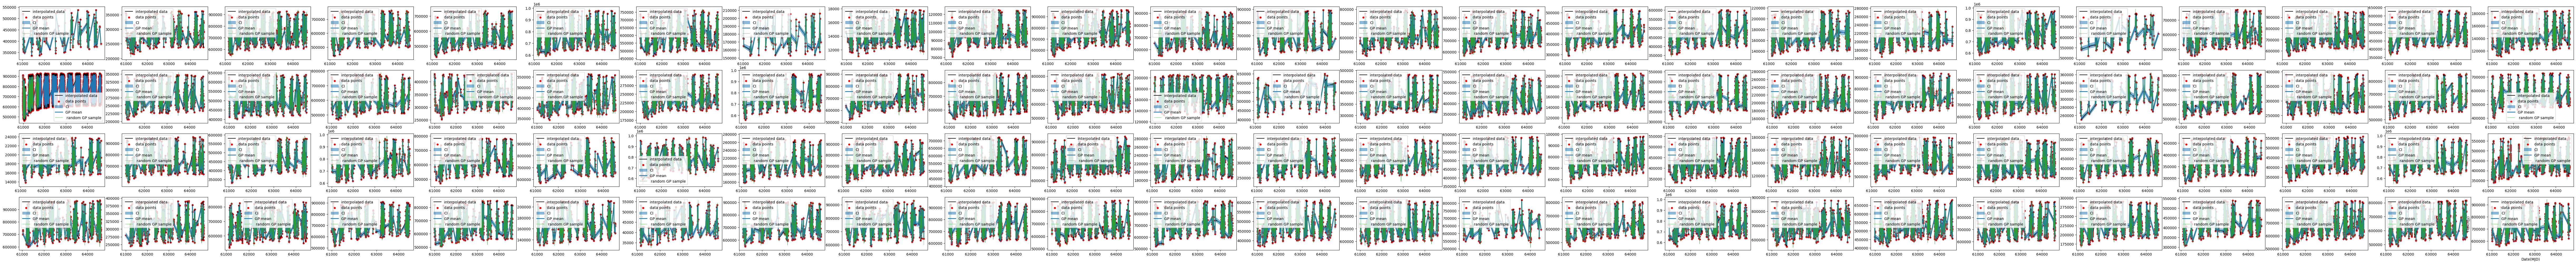

In [84]:
# data = [["id", "bh_mass_lg_mass", "AGN_0_edd_ratio", "flux_perfect", "mu avg.", "mu sd", "var avg.", "var sd."]]
data = [["id", "flux_perfect", "mu avg.", "mu sd", "var avg.", "var sd."]]

raw_vals = []

# data = jnp.asarray(df.loc[0, "lightcurve"][["mjd", "flux_perfect"]].to_numpy())

def build_gp_var_fixed(theta: tuple[Param], x: jnp.ndarray) -> GaussianProcess:
    """ Build a Gaussian Process with the given parameters and input data.
    Precondition: theta is a tuple of (log_sigma, log_scale) parameters.
    """
    log_sigma, log_scale = theta
    kernel = kernels.quasisep.Exp(scale=jnp.exp(log_scale), sigma=jnp.exp(log_sigma))
    return GaussianProcess(kernel, x, diag=0.05)

def neg_log_likelihood_var_fixed(theta, X, y):
    gp = build_gp_var_fixed(theta, X)
    return -gp.log_probability(y)

solver = jaxopt.ScipyMinimize(fun=neg_log_likelihood_var_fixed)

scale = Param("scale", value=100.0, shape=(), description="scale parameter")
sigma = Param("sigma", value=1.01, shape=(), description="sigma parameter")
theta = (jnp.log(float(sigma.value)), jnp.log(float(scale.value)))

fig, axes = plt.subplots(nrows=4, ncols=math.ceil(n/4), figsize=(125, 12))
axes = axes.flatten()

for i in range(n):
    lightcurve = df.loc[i, "lightcurve"]
    if lightcurve is None or "flux_perfect" not in lightcurve.columns:
        print(f"Warning: Sample {i} has no lightcurve data or missing 'flux_perfect' column. Skipping.")
        continue
    sample_data = jnp.asarray(df.loc[i, "lightcurve"][["mjd", "flux_perfect"]].to_numpy())
    x = sample_data[:, 0]
    x_std = x - jnp.mean(x)
    y = sample_data[:, 1]
    y_mean = jnp.mean(y)
    y_sd = jnp.std(y)
    y_stand = (y - y_mean)/y_sd
    if jnp.any(jnp.isnan(y)):
        print(f"Warning: Sample {i} has NaN standardized flux values. Skipping.")
        continue
    soln = solver.run(theta, X=x_std, y=y_stand)
    gp = build_gp_var_fixed(soln.params, x_std)
    cond_gp = gp.condition(y_stand).gp
    mu, var = cond_gp.loc, jnp.clip(cond_gp.variance, 0, None)
    raw_vals.append([mu, var])
    data.append([
        df.loc[i, "id"],
        # df.loc[i,"bh_mass_lg_mass"],
        # df.loc[i, "AGN_0_edd_ratio"],
        df.loc[i, "lightcurve"]["flux_perfect"].mean(),
        float(mu.mean()),
        float(mu.std()),
        float(var.mean()),
        float(var.std()),
    ])
    ax = axes[i]
    ax.plot(x, y, color = "k")
    ax.scatter(x, y, color="red", s=20)
    ax.fill_between(x, y_mean + y_sd * (mu + np.sqrt(var)), y_mean + y_sd * (mu - np.sqrt(var)), color="C0", alpha=0.5)
    ax.plot(x, y_mean + y_sd * mu, color="C0", lw=2)
    ax.plot(x, y_mean + y_sd * cond_gp.sample(jax.random.PRNGKey(42)), color="C2", lw=0.5)
    ax.legend(["interpolated data", "data points", "CI", "GP mean", " random GP sample"])
    plt.xlabel("Date(MJD)")
    _ = plt.ylabel("Flux(nJy)")


In [85]:
data = np.asarray(data)
print(data)
pd.DataFrame(data).to_csv("agn_gp_results_fixedmassnedd.csv", index=False)

[['id' 'flux_perfect' 'mu avg.' 'mu sd' 'var avg.' 'var sd.']
 ['0' '425888.6368164089' '0.0006865472532808781' '0.9486908316612244'
  '0.04224202409386635' '0.008560656569898129']
 ['1' '281661.45887560566' '-0.0005846048588864505' '0.9532464146614075'
  '0.040214668959379196' '0.008683648891746998']
 ['2' '730430.729882145' '3.797408453465323e-06' '0.9526990652084351'
  '0.04274354502558708' '0.008172115311026573']
 ['3' '592757.6976802454' '-0.00018487084889784455' '0.9537181854248047'
  '0.040985818952322006' '0.009082318283617496']
 ['4' '570234.883753609' '-0.000541764369700104' '0.9519528150558472'
  '0.04201306402683258' '0.007667331490665674']
 ['5' '758132.8858058145' '-0.000399649579776451' '0.9512672424316406'
  '0.04496728256344795' '0.007667268626391888']
 ['6' '594873.2300384599' '-0.00012650298594962806' '0.9532554745674133'
  '0.04137130826711655' '0.008576801978051662']
 ['7' '177881.4940434728' '-0.0008047522860579193' '0.9508783221244812'
  '0.04322279989719391' '0.

In [86]:
print(raw_vals)
pd.DataFrame(raw_vals).to_csv("raw_vals_fixedmassnedd.csv", index=False)

[[Array([ 1.9373087 ,  1.1960764 ,  1.8669314 ,  1.0436578 ,  0.32452443,
       -1.2209014 , -1.3194114 , -0.38276637, -0.80817807,  0.921499  ,
        0.22899161, -0.9601576 , -1.4646158 ,  0.9608153 ,  0.09756191,
        0.08501441, -0.4431521 , -0.62525254, -0.6252526 , -1.0905803 ,
       -1.0905803 , -1.4474885 , -1.5945227 , -1.4969335 , -1.4979831 ,
        0.07544059,  0.9900159 ,  0.4206403 , -0.62575597, -0.30668145,
       -1.459682  , -1.829111  , -0.9577575 , -0.9577578 , -0.32222995,
       -0.3222297 ,  0.50038826,  1.3182676 , -0.778188  , -0.72194755,
       -0.81198287,  0.34901187,  1.2518053 , -0.6278195 , -0.0600935 ,
        1.1815405 , -0.13926834,  0.02014708,  0.8295093 , -0.01886299,
        0.43925688, -0.56943226,  0.4712542 , -0.5137745 ,  0.04998629,
       -0.7455896 ,  0.09661897, -1.2414992 , -0.8939285 , -0.4658315 ,
       -0.46583214, -1.0925524 , -0.76669633, -0.45226467, -0.4522642 ,
       -0.72698784, -0.30570158, -0.3057011 , -0.71743065, -0.

In [87]:
df = pd.read_csv("agn_gp_results_fixedmassnedd.csv", index_col=0)
print(df.head())
print(df.columns.tolist())



                     1                        2                   3  \
0                                                                     
id        flux_perfect                  mu avg.               mu sd   
0    425888.6368164089    0.0006865472532808781  0.9486908316612244   
1   281661.45887560566   -0.0005846048588864505  0.9532464146614075   
2     730430.729882145    3.797408453465323e-06  0.9526990652084351   
3    592757.6976802454  -0.00018487084889784455  0.9537181854248047   

                       4                     5  
0                                               
id              var avg.               var sd.  
0    0.04224202409386635  0.008560656569898129  
1   0.040214668959379196  0.008683648891746998  
2    0.04274354502558708  0.008172115311026573  
3   0.040985818952322006  0.009082318283617496  
['1', '2', '3', '4', '5']


In [88]:
mu_mean = df.loc[:, "mu avg."]
mu_sd = df.loc[:, "mu sd"] # forgot the point, my bad :/
var_mean = df.loc[:, "var avg."]
var_sd = df.loc[:, "var sd."]   
bh_mass = df.loc[:, "bh_mass_lg_mass"]
edd_ratio = df.loc[:, "AGN_0_edd_ratio"]

plt.scatter(bh_mass, mu_mean)
plt.scatter(bh_mass, var_mean, color = "orange")
plt.xlabel("Black Hole Mass (log scale)")
plt.ylabel("Avg. GP Mean and Variance")
plt.title("Avg. GP Mean and Variance vs. Black Hole Mass")
plt.legend(["GP Mean", "GP Variance"])
plt.show()


plt.scatter(edd_ratio, mu_mean)
plt.scatter(edd_ratio, var_mean, color = "orange")
plt.xlabel("Eddington Ratio")
plt.ylabel("Avg. GP Mean and Variance")
plt.title("Avg. GP Mean and Variance vs. Eddington Ratio")
plt.legend(["GP Mean", "GP Variance"])
plt.show()


KeyError: 'mu avg.'

<Axes: >

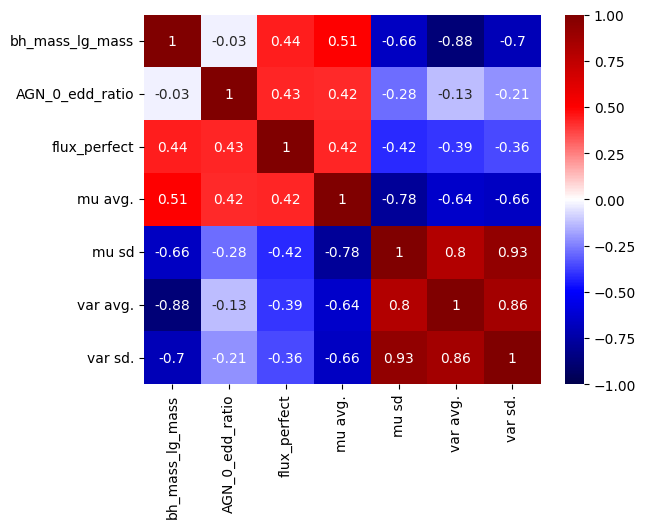

In [ ]:
import seaborn as sns
corr = df.select_dtypes('number').corr()
sns.heatmap(corr, vmin=-1, vmax=1, center=0, annot=True, cmap='seismic')